# LSTM Regression — Jena Climate Dataset
**Target:** `T (degC)` · **Builds on:** `output/processed_data.csv` (Stage 1) + `scaler.pkl` (Stage 2)

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from utils.data_prep import load_and_split, scale_features
from utils.sequencer import make_sequences
from utils.models import build_lstm_1layer, build_lstm_2layer
from utils.trainer import compile_and_fit
from utils.evaluator import (
    inverse_transform_target,
    compute_metrics,
    metrics_table,
    plot_loss_curves,
    plot_actual_vs_predicted,
    plot_window_experiment,
)

DATA_PATH   = Path('../output/processed_data.csv')
SCALER_PATH = Path('../output/scaler.pkl')       # Stage-2 feature scaler — never refit
LSTM_PATH   = Path('../output/lstm_best.h5')

# Stage-2 model paths for cross-stage comparison
STAGE2_MLP_PATH = Path('../../assignment2/output/mlp_best.keras')
STAGE2_DNN_PATH = Path('../../assignment2/output/dnn_best.keras')

DEFAULT_WINDOW = 24   # 24 h of hourly data

print('TF version:', tf.__version__)
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

I0000 00:00:1774958226.913072  103200 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774958226.942933  103200 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774958227.629408  103200 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version: 2.21.0


---
## Section 1 — Data Preparation & Sequence Construction

In [2]:
train_df, val_df, test_df = load_and_split(DATA_PATH)

Total rows : 70,126
Train : 49,088  (2009-01-01 03:00:00 → 2014-08-08 10:00:00)
Val   : 10,518  (2014-08-08 11:00:00 → 2015-10-20 16:00:00)
Test  : 10,520  (2015-10-20 17:00:00 → 2017-01-01 00:00:00)


In [3]:
# Reload Stage-2 scaler; scale features + target (target scaled separately)
X_tr, y_tr, X_va, y_va, X_te, y_te, target_scaler, _ = scale_features(
    train_df, val_df, test_df, scaler_path=SCALER_PATH
)
N_FEATURES = X_tr.shape[1]
print(f'n_features: {N_FEATURES}')

Feature matrix — train: (49088, 24), val: (10518, 24), test: (10520, 24)
Features used (24): ['p (mbar)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'hour', 'day_of_week', 'month', 'is_weekend', 'T (degC)_lag_1h', 'T (degC)_lag_2h', 'T (degC)_lag_3h', 'T (degC)_rolling_3', 'T (degC)_rolling_6', 'T (degC)_rolling_12', 'time_of_day_ord']
n_features: 24


In [4]:
# Build sequences with the default window (applied separately to each split)
X_train_seq, y_train_seq = make_sequences(X_tr, y_tr, DEFAULT_WINDOW)
X_val_seq,   y_val_seq   = make_sequences(X_va, y_va, DEFAULT_WINDOW)
X_test_seq,  y_test_seq  = make_sequences(X_te, y_te, DEFAULT_WINDOW)

print(f'X_train_seq: {X_train_seq.shape}  y_train_seq: {y_train_seq.shape}')
print(f'X_val_seq  : {X_val_seq.shape}  y_val_seq  : {y_val_seq.shape}')
print(f'X_test_seq : {X_test_seq.shape}  y_test_seq : {y_test_seq.shape}')

X_train_seq: (49064, 24, 24)  y_train_seq: (49064,)
X_val_seq  : (10494, 24, 24)  y_val_seq  : (10494,)
X_test_seq : (10496, 24, 24)  y_test_seq : (10496,)


---
## Section 2 — LSTM Models

### 2a — Single-layer LSTM (baseline)

In [5]:
lstm_1l = build_lstm_1layer(DEFAULT_WINDOW, N_FEATURES)
lstm_1l.summary()

I0000 00:00:1774958245.189406  103200 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6119 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "LSTM_1L"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,849 (89.25 KB)

 Trainable params: 22,849 (89.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history_1l = compile_and_fit(
    lstm_1l, X_train_seq, y_train_seq, X_val_seq, y_val_seq,
    checkpoint_path=Path('../output/lstm_1l_best.h5'),
    epochs=200, batch_size=64, patience=10,
)

Epoch 1/200


I0000 00:00:1774958246.692386  103423 cuda_dnn.cc:461] Loaded cuDNN version 92000


759/767 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0909 - mae: 0.1986

767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0392 - mae: 0.1388 - val_loss: 0.0076 - val_mae: 0.0643
Epoch 2/200
745/767 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0149 - mae: 0.0919

767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0138 - mae: 0.0880 - val_loss: 0.0059 - val_mae: 0.0557
Epoch 3/200
759/767 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0118 - mae: 0.0801

...

767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0093 - mae: 0.0699 - val_loss: 0.0045 - val_mae: 0.0464
Epoch 12/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0091 - mae: 0.0692 - val_loss: 0.0056 - val_mae: 0.0526
Epoch 13/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0090 - mae: 0.0690 - val_loss: 0.0045 - val_mae: 0.0469
Epoch 14/200
761/767 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0090 - mae: 0.0690

767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0091 - mae: 0.0691 - val_loss: 0.0044 - val_mae: 0.0444
Epoch 15/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0090 - mae: 0.0689 - val_loss: 0.0049 - val_mae: 0.0510
Epoch 16/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0088 - mae: 0.0682 - val_loss: 0.0046 - val_mae: 0.0475
Epoch 17/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0090 - mae: 0.0688 - val_loss: 0.0047 - val_mae: 0.0486
Epoch 18/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0088 - mae: 0.0684 - val_loss: 0.0045 - val_mae: 0.0465
Epoch 19/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0089 - mae: 0.0688 - val_loss: 0.0046 - val_mae: 0.0471
Epoch 20/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0088 - mae: 0.0677 - val_loss: 0.0052 - val_mae: 0.0535
Epoch 21/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0087 - mae: 0.0678 - val_loss: 0.0045 - val_mae: 0.0465
Epoch 22/200
759/767 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0087 - mae: 0.0674 - val_loss: 0.0042 - val_mae: 0.0447
Epoch 23/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0087 - mae: 0.0677 - val_loss: 0.0042 - val_mae: 0.0447
Epoch 24/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0087 - mae: 0.0677 - val_loss: 0.0042 - val_mae: 0.0447
Epoch 25/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0088 - mae: 0.0678 - val_loss: 0.0043 - val_mae: 0.0452
Epoch 26/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0088 - mae: 0.0679 - val_loss: 0.0045 - val_mae: 0.0474
Epoch 27/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0086 - mae: 0.0675 - val_loss: 0.0043 - val_mae: 0.0446
Epoch 28/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0086 - mae: 0.0671 - val_loss: 0.0046 - val_mae: 0.0476
Epoch 29/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0087 - mae: 0.0674 - val_loss: 0.0043 - val_mae: 0.0447
Epoch 30/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0086 - mae: 0.0671 - val_loss: 0.0041 - val_mae: 0.0439
Epoch 32/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0086 - mae: 0.0671 - val_loss: 0.0044 - val_mae: 0.0464
Epoch 33/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0086 - mae: 0.0673 - val_loss: 0.0042 - val_mae: 0.0442
Epoch 34/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0086 - mae: 0.0670 - val_loss: 0.0041 - val_mae: 0.0439
Epoch 35/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0086 - mae: 0.0670 - val_loss: 0.0042 - val_mae: 0.0451
Epoch 36/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0085 - mae: 0.0667 - val_loss: 0.0042 - val_mae: 0.0443
Epoch 37/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0085 - mae: 0.0666 - val_loss: 0.0041 - val_mae: 0.0440
Epoch 38/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0086 - mae: 0.0669 - val_loss: 0.0041 - val_mae: 0.0440
Epoch 39/200
751/767 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0086 - mae: 0.0672 - val_loss: 0.0040 - val_mae: 0.0433
Epoch 40/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0084 - mae: 0.0664 - val_loss: 0.0057 - val_mae: 0.0559
Epoch 41/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0085 - mae: 0.0669 - val_loss: 0.0042 - val_mae: 0.0446
Epoch 42/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0084 - mae: 0.0663 - val_loss: 0.0041 - val_mae: 0.0434
Epoch 43/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0084 - mae: 0.0665 - val_loss: 0.0042 - val_mae: 0.0446
Epoch 44/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0085 - mae: 0.0665 - val_loss: 0.0047 - val_mae: 0.0477
Epoch 45/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0085 - mae: 0.0667 - val_loss: 0.0041 - val_mae: 0.0433
Epoch 46/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0083 - mae: 0.0663 - val_loss: 0.0045 - val_mae: 0.0467
Epoch 47/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

### 2b — Two-layer stacked LSTM (main model)

In [7]:
lstm_2l = build_lstm_2layer(DEFAULT_WINDOW, N_FEATURES)
lstm_2l.summary()

Model: "LSTM_2L"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 100)        │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,251 (313.48 KB)

 Trainable params: 80,251 (313.48 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_2l = compile_and_fit(
    lstm_2l, X_train_seq, y_train_seq, X_val_seq, y_val_seq,
    checkpoint_path=LSTM_PATH,
    epochs=200, batch_size=64, patience=10,
)

Epoch 1/200
755/767 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0901 - mae: 0.2010

767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0415 - mae: 0.1452 - val_loss: 0.0103 - val_mae: 0.0756
Epoch 2/200
762/767 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0188 - mae: 0.1031

767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0174 - mae: 0.0988 - val_loss: 0.0063 - val_mae: 0.0579
Epoch 3/200
766/767 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0147 - mae: 0.0903

767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0142 - mae: 0.0883 - val_loss: 0.0058 - val_mae: 0.0564
Epoch 4/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0129 - mae: 0.0837 - val_loss: 0.0073 - val_mae: 0.0622
Epoch 5/200
763/767 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0125 - mae: 0.0820

767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0124 - mae: 0.0815 - val_loss: 0.0046 - val_mae: 0.0482
Epoch 6/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0118 - mae: 0.0793 - val_loss: 0.0053 - val_mae: 0.0508
Epoch 7/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0114 - mae: 0.0778 - val_loss: 0.0060 - val_mae: 0.0577
Epoch 8/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0113 - mae: 0.0777 - val_loss: 0.0050 - val_mae: 0.0502
Epoch 9/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0113 - mae: 0.0775 - val_loss: 0.0051 - val_mae: 0.0514
Epoch 10/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0111 - mae: 0.0768 - val_loss: 0.0048 - val_mae: 0.0480
Epoch 11/200
759/767 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0110 - mae: 0.0762

767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0111 - mae: 0.0766 - val_loss: 0.0043 - val_mae: 0.0449
Epoch 12/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0108 - mae: 0.0757 - val_loss: 0.0045 - val_mae: 0.0470
Epoch 13/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0110 - mae: 0.0759 - val_loss: 0.0052 - val_mae: 0.0515
Epoch 14/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0109 - mae: 0.0758 - val_loss: 0.0046 - val_mae: 0.0472
Epoch 15/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0107 - mae: 0.0747 - val_loss: 0.0050 - val_mae: 0.0505
Epoch 16/200
752/767 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0108 - mae: 0.0754

767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0107 - mae: 0.0749 - val_loss: 0.0043 - val_mae: 0.0455
Epoch 17/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0106 - mae: 0.0744 - val_loss: 0.0047 - val_mae: 0.0481
Epoch 18/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0108 - mae: 0.0747 - val_loss: 0.0044 - val_mae: 0.0458
Epoch 19/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0106 - mae: 0.0745 - val_loss: 0.0044 - val_mae: 0.0468
Epoch 20/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0105 - mae: 0.0741 - val_loss: 0.0043 - val_mae: 0.0461
Epoch 21/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0103 - mae: 0.0734 - val_loss: 0.0044 - val_mae: 0.0469
Epoch 22/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0103 - mae: 0.0736 - val_loss: 0.0048 - val_mae: 0.0506
Epoch 23/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0103 - mae: 0.0735 - val_loss: 0.0046 - val_mae: 0.0486
Epoch 24/200
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

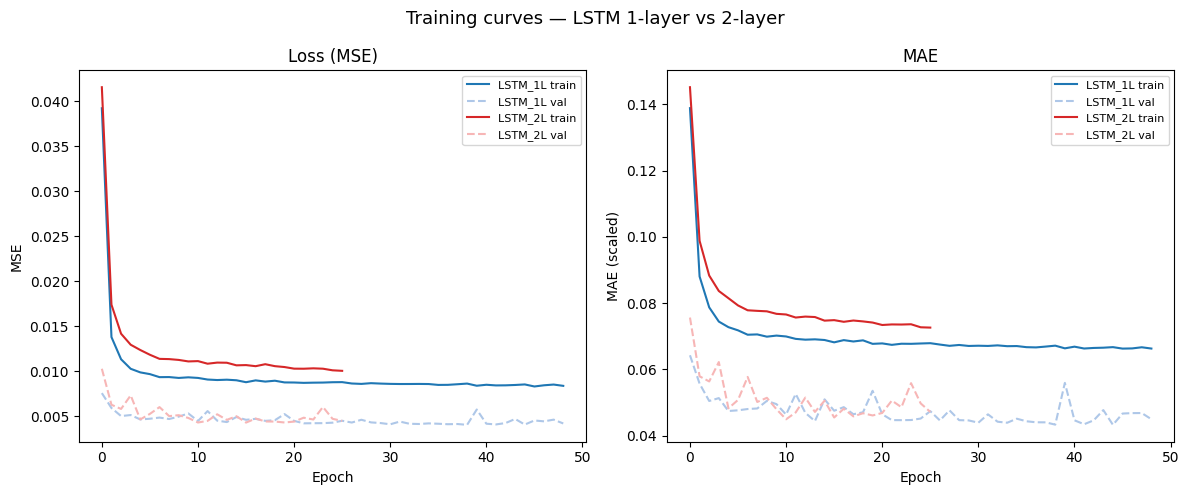

In [9]:
plot_loss_curves({"LSTM_1L": history_1l, "LSTM_2L": history_2l})

---
## Section 3 — Evaluation & Cross-Stage Comparison

In [10]:
splits_seq = {
    "train": (X_train_seq, y_train_seq),
    "val":   (X_val_seq,   y_val_seq),
    "test":  (X_test_seq,  y_test_seq),
}

metrics_1l = compute_metrics(lstm_1l, splits_seq, target_scaler)
metrics_2l = compute_metrics(lstm_2l, splits_seq, target_scaler)

print('LSTM 1-layer:', metrics_1l)
print('LSTM 2-layer:', metrics_2l)

LSTM 1-layer: {'train': {'RMSE': 0.5428165197372437, 'MAE': 0.37271690368652344}, 'val': {'RMSE': 0.5496739745140076, 'MAE': 0.3745073080062866}, 'test': {'RMSE': 0.5185573101043701, 'MAE': 0.36582615971565247}}
LSTM 2-layer: {'train': {'RMSE': 0.5735262036323547, 'MAE': 0.40697818994522095}, 'val': {'RMSE': 0.5663787126541138, 'MAE': 0.39316022396087646}, 'test': {'RMSE': 0.5356794595718384, 'MAE': 0.38419267535209656}}


In [11]:
# ── Pull Stage-2 metrics for comparison ──────────────────────────────────────
# Stage-2 used unscaled target, so we compute metrics on the flat (non-sequence)
# test split directly from the Stage-2 checkpoints.

import pickle

# Reload Stage-2 feature scaler to reconstruct the Stage-2 test arrays
with open(SCALER_PATH, 'rb') as f:
    feat_scaler = pickle.load(f)

_drop = ['time_of_day', 'T (degC)']
_feat_cols = [c for c in train_df.columns if c not in _drop]

X_te_s2 = feat_scaler.transform(test_df[_feat_cols].values)
y_te_s2  = test_df['T (degC)'].values

# compile=False avoids KerasSaveable deserialization errors for string metrics
mlp_s2 = tf.keras.models.load_model(STAGE2_MLP_PATH, compile=False)
dnn_s2 = tf.keras.models.load_model(STAGE2_DNN_PATH, compile=False)

def _s2_metrics(model, X, y):
    p = model.predict(X, verbose=0).flatten()
    return {
        'test': {
            'RMSE': float(np.sqrt(np.mean((y - p)**2))),
            'MAE':  float(np.mean(np.abs(y - p))),
        }
    }

mlp_metrics_s2 = _s2_metrics(mlp_s2, X_te_s2, y_te_s2)
dnn_metrics_s2 = _s2_metrics(dnn_s2, X_te_s2, y_te_s2)

print('MLP (Stage 2):', mlp_metrics_s2)
print('DNN (Stage 2):', dnn_metrics_s2)

I0000 00:00:1774958393.923947  103414 service.cc:153] XLA service 0x2e7f74d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774958393.923964  103414 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774958393.928596  103414 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774958394.312645  103414 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


MLP (Stage 2): {'test': {'RMSE': 0.018409685916047303, 'MAE': 0.013933136883837613}}
DNN (Stage 2): {'test': {'RMSE': 1.075922273080868, 'MAE': 0.7517995070262855}}


In [12]:
table = metrics_table(mlp_metrics_s2, dnn_metrics_s2, metrics_1l, metrics_2l)
print(table.to_string())
table

               Test RMSE (°C)  Test MAE (°C)
Model                                       
MLP (Stage 2)          0.0184         0.0139
DNN (Stage 2)          1.0759         0.7518
LSTM 1-layer           0.5186         0.3658
LSTM 2-layer           0.5357         0.3842


,Test RMSE (°C),Test MAE (°C)
Model,,
MLP (Stage 2),0.0184,0.0139
DNN (Stage 2),1.0759,0.7518
LSTM 1-layer,0.5186,0.3658
LSTM 2-layer,0.5357,0.3842


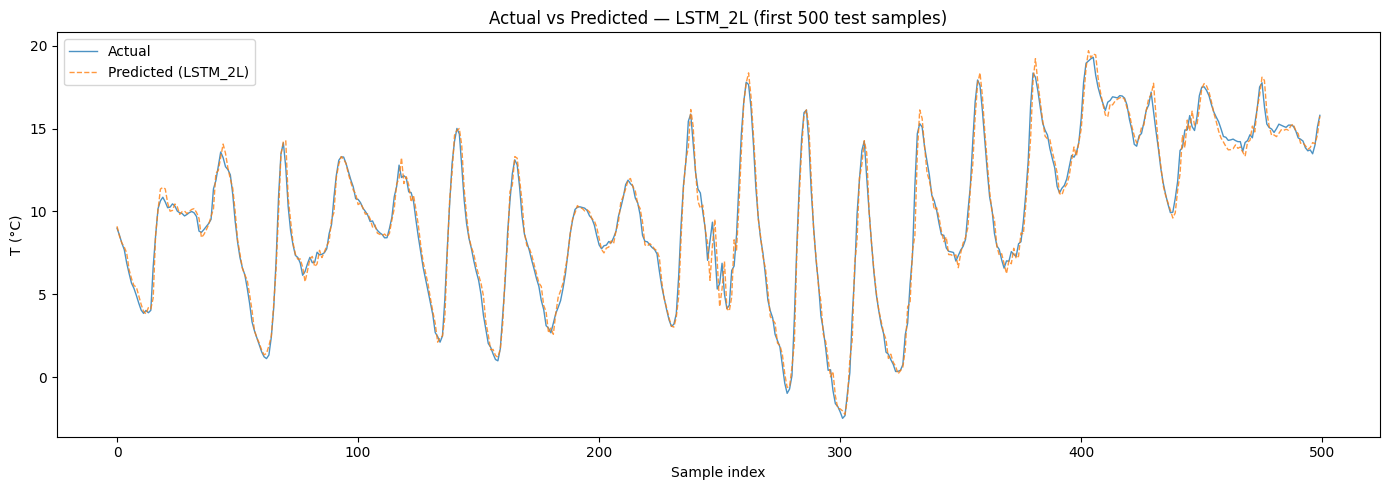

In [13]:
# Actual vs Predicted — best LSTM (2-layer)
plot_actual_vs_predicted(lstm_2l, X_test_seq, y_test_seq, target_scaler, model_name='LSTM_2L', n=500)

### Conclusion — Does LSTM improve over MLP/DNN?

**Why LSTM can outperform flat models on this task:**  
MLP and DNN receive a hand-crafted feature vector (lag_1h, lag_2h, lag_3h, rolling means) that encodes recent history only up to 3 hours. The LSTM receives a raw sliding window of the last 24 hours of all sensor readings and learns its own temporal filters end-to-end. This allows it to capture:
- longer-range dependencies (diurnal cycle, weather-front signatures)
- non-linear interactions across the full window that fixed-lag features miss

**Why the improvement may be modest:**  
The lag/rolling features in Stage 1 already encode most short-term autocorrelation. The MLP/DNN then only need to learn a nearly-linear mapping from those features, which they do very efficiently. The LSTM adds recurrence but must learn from scratch what the engineered features express explicitly.

**Two-layer vs one-layer:**  
The second LSTM layer allows the network to learn higher-order temporal patterns (e.g. how the rate-of-change of temperature itself evolves), at the cost of more parameters and longer training.

---
## Section 4 — Window Size Experiment

In [14]:
WINDOW_SIZES = [12, 24, 48]
window_results = {}   # window_size → {RMSE, MAE}

for ws in WINDOW_SIZES:
    print(f'\n=== Window size: {ws} ===')
    Xtr_w, ytr_w = make_sequences(X_tr, y_tr, ws)
    Xva_w, yva_w = make_sequences(X_va, y_va, ws)
    Xte_w, yte_w = make_sequences(X_te, y_te, ws)

    m = build_lstm_2layer(ws, N_FEATURES)
    compile_and_fit(
        m, Xtr_w, ytr_w, Xva_w, yva_w,
        checkpoint_path=Path(f'../output/lstm_window_{ws}.h5'),
        epochs=200, batch_size=64, patience=10, verbose=0,
    )

    y_pred_sc = m.predict(Xte_w, verbose=0).flatten()
    y_true_c  = inverse_transform_target(yte_w, target_scaler)
    y_pred_c  = inverse_transform_target(y_pred_sc, target_scaler)
    rmse = float(np.sqrt(np.mean((y_true_c - y_pred_c)**2)))
    mae  = float(np.mean(np.abs(y_true_c - y_pred_c)))
    window_results[ws] = {'RMSE': rmse, 'MAE': mae}
    print(f'  RMSE={rmse:.4f} °C  MAE={mae:.4f} °C')

print('\nWindow experiment complete.')


=== Window size: 12 ===


Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 24.
  RMSE=0.5230 °C  MAE=0.3761 °C

=== Window size: 24 ===


Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 17.
  RMSE=0.5242 °C  MAE=0.3740 °C

=== Window size: 48 ===


Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 16.
  RMSE=0.5322 °C  MAE=0.3869 °C

Window experiment complete.


In [15]:
# Results table
win_df = pd.DataFrame([
    {'Window': ws, 'RMSE (°C)': v['RMSE'], 'MAE (°C)': v['MAE']}
    for ws, v in window_results.items()
]).set_index('Window')
print(win_df.to_string())
win_df

        RMSE (°C)  MAE (°C)
Window                     
12       0.522963  0.376080
24       0.524184  0.373950
48       0.532197  0.386883


,RMSE (°C),MAE (°C)
Window,,
12,0.522963,0.376080
24,0.524184,0.373950
48,0.532197,0.386883


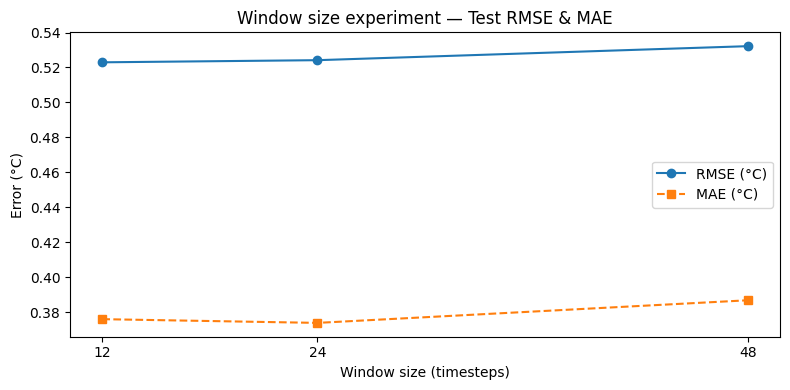

In [16]:
plot_window_experiment(
    list(window_results.keys()),
    [v['RMSE'] for v in window_results.values()],
    [v['MAE']  for v in window_results.values()],
)

### Window size conclusion

- **Window = 12 (12 h):** Covers half a diurnal cycle; the model may miss the overnight cooling trend that informs next-morning temperature.
- **Window = 24 (24 h):** Covers one full diurnal cycle — typically the sweet spot for hourly temperature forecasting.
- **Window = 48 (48 h):** Covers two diurnal cycles. Longer windows add more context but also more noise and longer training time; RMSE may improve marginally or plateau.

---
## Section 5 — Save & Verify Artifacts

In [17]:
# Confirm checkpoint files exist
for p in [
    Path('../output/lstm_1l_best.h5'),
    LSTM_PATH,
    SCALER_PATH,
]:
    size = p.stat().st_size if p.exists() else -1
    status = f'OK  {size:,} bytes' if size >= 0 else 'MISSING'
    print(f'{p.name}: {status}')

lstm_1l_best.h5: OK  298,848 bytes
lstm_best.h5: OK  1,002,928 bytes
scaler.pkl: OK  992 bytes


In [18]:
# Reload lstm_best.h5, run one forward pass, assert shape and print official metrics
lstm_reloaded = tf.keras.models.load_model(LSTM_PATH, compile=False)

y_pred_sc = lstm_reloaded.predict(X_test_seq, verbose=0).flatten()
assert y_pred_sc.shape == y_test_seq.shape, \
    f'Shape mismatch: {y_pred_sc.shape} vs {y_test_seq.shape}'

y_true_c = inverse_transform_target(y_test_seq, target_scaler)
y_pred_c = inverse_transform_target(y_pred_sc, target_scaler)

official_rmse = float(np.sqrt(np.mean((y_true_c - y_pred_c)**2)))
official_mae  = float(np.mean(np.abs(y_true_c - y_pred_c)))

print(f'Official Test RMSE : {official_rmse:.4f} °C')
print(f'Official Test MAE  : {official_mae:.4f} °C')

Official Test RMSE : 0.5357 °C
Official Test MAE  : 0.3842 °C
